# Transformers for Rainfall-Runoff: the Leaf River Catchment

## Motivation

The LSTM notebook showed that sequence memory matters: NSE climbs as we extend the lookback window to ~180 days. But the LSTM reads the sequence **one step at a time** — day 1, day 2, …, day 365. This creates two problems:

1. **Sequential bottleneck.** Information from day 1 must survive through 364 gating operations to reach the final hidden state. Long-range dependencies are hard to learn.
2. **No parallelism.** Step $t$ depends on step $t-1$, so training cannot be parallelised across the time dimension.

The **Transformer** (Vaswani et al., 2017) solves both problems with a single mechanism: **self-attention**. Rather than piping information through a chain of hidden states, every position in the sequence is allowed to **directly look at** every other position and decide how much to borrow from it. In hydrological terms: when predicting today's streamflow, the model can look directly at last week's precipitation *and* a wet spell from three months ago — without having to "remember" that signal through hundreds of gating operations.

## What we'll cover

1. Reuse the Leaf River dataset and preprocessing from the LSTM notebook
2. Build self-attention **from scratch** — framed as a learned weighted average (regression, not language modelling)
3. Add positional encoding so the model knows which day is which
4. Stack attention layers into an **encoder-only Transformer** for regression
5. Train and compare with the LSTM baseline
6. Visualise the **attention weights** — which past days does the model attend to?

## Earth science connection

Catchment hydrology is full of processes with variable lags: a snowmelt signal may arrive weeks after accumulation, while an intense convective storm produces runoff within hours. Attention lets the model learn a **data-driven lag structure** rather than imposing a fixed decay (as in linear transfer functions) or relying on a chain of hidden states (as in LSTMs).

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import math

rng = np.random.default_rng(42)
torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


## 1. Data (same pipeline as the LSTM notebook)

We reuse the exact same Leaf River dataset, train/val/test split, and normalisation. The only thing that changes is the model.

In [2]:
df = pd.read_csv('../../data/LeafRiverDaily.csv')
df.columns = ['Precipitation', 'Temperature', 'Streamflow']
df.index = pd.date_range(start='1948-01-01', periods=len(df), freq='D')

n = len(df)
n_train = int(0.60 * n)
n_val   = int(0.20 * n)
n_test  = n - n_train - n_val

train_df = df.iloc[:n_train].copy()
val_df   = df.iloc[n_train:n_train + n_val].copy()
test_df  = df.iloc[n_train + n_val:].copy()

# --- Normalise inputs ---
input_cols = ['Precipitation', 'Temperature']
scaler_x = StandardScaler()
train_x = scaler_x.fit_transform(train_df[input_cols].values)
val_x   = scaler_x.transform(val_df[input_cols].values)
test_x  = scaler_x.transform(test_df[input_cols].values)

# --- Log-normalise streamflow ---
eps = 1e-6
train_q_raw = train_df['Streamflow'].values
val_q_raw   = val_df['Streamflow'].values
test_q_raw  = test_df['Streamflow'].values

train_q_log = np.log(train_q_raw + eps)
q_mean, q_std = train_q_log.mean(), train_q_log.std()
train_q = (train_q_log - q_mean) / q_std
val_q   = (np.log(val_q_raw   + eps) - q_mean) / q_std
test_q  = (np.log(test_q_raw  + eps) - q_mean) / q_std

print(f"Train: {len(train_df)} days  |  Val: {len(val_df)} days  |  Test: {len(test_df)} days")

Train: 6576 days  |  Val: 2192 days  |  Test: 2192 days


In [3]:
LOOKBACK = 365  # same as LSTM notebook

class HydrologyDataset(Dataset):
    def __init__(self, x, q, lookback):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.q = torch.tensor(q, dtype=torch.float32)
        self.lookback = lookback

    def __len__(self):
        return len(self.q) - self.lookback

    def __getitem__(self, idx):
        x_window = self.x[idx : idx + self.lookback]        # [L, F]
        y_target = self.q[idx + self.lookback].unsqueeze(0)  # [1]
        return x_window, y_target

train_ds = HydrologyDataset(train_x, train_q, LOOKBACK)
val_ds   = HydrologyDataset(val_x,   val_q,   LOOKBACK)
test_ds  = HydrologyDataset(test_x,  test_q,  LOOKBACK)

train_dl = DataLoader(train_ds, batch_size=64,  shuffle=True)
val_dl   = DataLoader(val_ds,   batch_size=256, shuffle=False)
test_dl  = DataLoader(test_ds,  batch_size=256, shuffle=False)

xb, yb = next(iter(train_dl))
print(f"Batch shape — X: {xb.shape}  y: {yb.shape}")

Batch shape — X: torch.Size([64, 365, 2])  y: torch.Size([64, 1])


## 2. Self-attention as a learned weighted average

Before building the full architecture, let's understand the core mechanism.

### The problem: mixing information across time

We have a sequence of day-vectors $\mathbf{x}_1, \mathbf{x}_2, \ldots, \mathbf{x}_L$ (each day is a vector of features). We want to produce an **updated** representation $\mathbf{z}_t$ for each day $t$ that blends information from all other days — with the blend determined by how *relevant* each past day is.

The simplest version: just take a **weighted average**

$$\mathbf{z}_t = \sum_{s=1}^{L} \alpha_{ts}\, \mathbf{x}_s, \qquad \sum_s \alpha_{ts} = 1,\quad \alpha_{ts} \ge 0$$

where $\alpha_{ts}$ is how much day $t$ borrows from day $s$. If the weights were **fixed** (e.g. uniform), this would be a simple moving average. The Transformer makes them **input-dependent**: the weights are computed on-the-fly from the data.

### Queries, keys, and values

Each position $t$ is given three roles via learned linear projections:

| Role | Symbol | Intuition |
|------|--------|-----------|
| **Query** $\mathbf{q}_t = W_Q \mathbf{x}_t$ | what am I looking for? | "I am a dry summer day trying to find similar dry antecedent conditions" |
| **Key** $\mathbf{k}_s = W_K \mathbf{x}_s$ | what do I advertise? | "I am a rainy day with high antecedent moisture" |
| **Value** $\mathbf{v}_s = W_V \mathbf{x}_s$ | what information do I carry? | "here is my actual feature vector" |

The attention weight from position $t$ to position $s$ is

$$\alpha_{ts} = \text{softmax}\!\left(\frac{\mathbf{q}_t^\top \mathbf{k}_s}{\sqrt{d_k}}\right)$$

The dot product $\mathbf{q}_t^\top \mathbf{k}_s$ measures how well day $s$'s "advertisement" matches day $t$'s "query". The $\sqrt{d_k}$ scaling prevents the dot products from getting so large that the softmax saturates (all weight on one position).

Stacking all positions into matrices $Q, K, V \in \mathbb{R}^{L \times d_k}$:

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right) V$$

This is just **batched weighted regression**: each output row is a convex combination of value rows, with weights determined by query-key similarity.

> **No language modelling required.** The language model framing (tokens, words, masking) is just one application. Here our "tokens" are days, our "vocabulary" is the continuous meteorological feature space, and the task is regression — not next-word prediction.

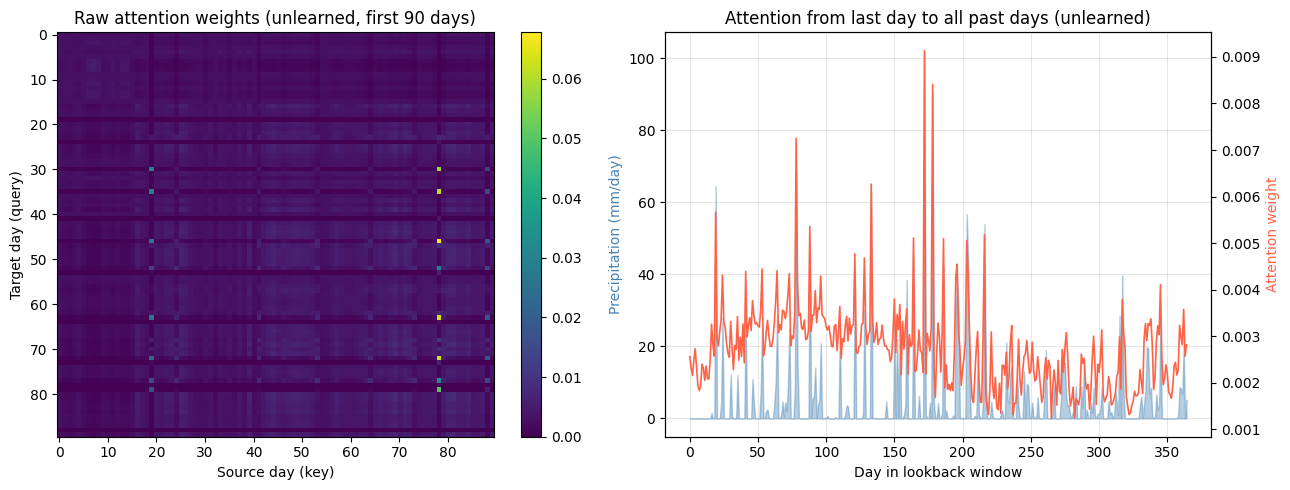

With random/unlearned projections, attention concentrates on days with
similar (P,T) vectors — not yet hydrologically meaningful.
After training, Q/K/V projections will learn to concentrate weight
on *functionally* similar antecedent conditions.


In [4]:
# --- Visualise the attention mechanism on a toy example ---

# Take a single 365-day window from the test set
x_example = test_x[:LOOKBACK]  # [365, 2]  (P_norm, T_norm)

# Unnormalise precipitation for plotting
p_mm = x_example[:, 0] * scaler_x.scale_[0] + scaler_x.mean_[0]
t_c  = x_example[:, 1] * scaler_x.scale_[1] + scaler_x.mean_[1]

# Compute a simple dot-product similarity kernel (no learned weights yet)
# treat each day as a 2-vector and compute cosine similarity matrix
X = torch.tensor(x_example, dtype=torch.float32)  # [L, 2]
# Scale by 1/sqrt(d_k), d_k=2
raw_scores = (X @ X.T) / math.sqrt(2)             # [L, L]
attn_naive = torch.softmax(raw_scores, dim=-1).numpy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: attention weight matrix (first 60 days for clarity)
N = 90
im = axes[0].imshow(attn_naive[:N, :N], aspect='auto', cmap='viridis',
                    interpolation='nearest')
axes[0].set_xlabel('Source day (key)')
axes[0].set_ylabel('Target day (query)')
axes[0].set_title('Raw attention weights (unlearned, first 90 days)')
plt.colorbar(im, ax=axes[0])
axes[0].grid(False)

# Right: for the last day in the window, what days receive most attention?
t_query = LOOKBACK - 1  # last day (the one we predict FOR)
attn_last = attn_naive[t_query, :]

days = np.arange(LOOKBACK)
axes[1].fill_between(days, p_mm, color='steelblue', alpha=0.4, label='Precip (mm/day)')
axes[1].set_ylabel('Precipitation (mm/day)', color='steelblue')
ax2 = axes[1].twinx()
ax2.plot(days, attn_last, color='tomato', lw=1.2, label='Attention weight')
ax2.set_ylabel('Attention weight', color='tomato')
axes[1].set_xlabel('Day in lookback window')
axes[1].set_title('Attention from last day to all past days (unlearned)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("With random/unlearned projections, attention concentrates on days with\n"
      "similar (P,T) vectors — not yet hydrologically meaningful.\n"
      "After training, Q/K/V projections will learn to concentrate weight\n"
      "on *functionally* similar antecedent conditions.")

## 3. Positional encoding

The attention operation above is **permutation-equivariant**: if we shuffle the day-rows, the output rows shuffle the same way. There is no notion of "day 5 comes before day 6". For language modelling this is solved with positional embeddings; for hydrology the ordering is crucial (we must not attend to future days when predicting today).

We add a **positional encoding** $\mathbf{p}_t$ to each input vector before the attention layers:

$$\tilde{\mathbf{x}}_t = \mathbf{x}_t + \mathbf{p}_t$$

The classic sinusoidal encoding uses sine and cosine at geometrically spaced frequencies:

$$p_{t,2i}   = \sin\!\left(\frac{t}{10000^{2i/d}}\right), \qquad
  p_{t,2i+1} = \cos\!\left(\frac{t}{10000^{2i/d}}\right)$$

where $d$ is the model dimension. These are essentially **Fourier modes at different periods**: the first pair has a period of $2\pi$ steps (~6 days), the last pair has a period of $10000 \cdot 2\pi$ steps (~170 years). Together they give each day a unique "fingerprint" that the model can use to distinguish yesterday from last month.

> **Physical analogy**: in signal processing we decompose a time series into sinusoidal components. The positional encoding does the opposite — it *adds* sinusoidal structure to the input so the model can read off the time index from the features. Since our data has seasonal cycles, these periodic basis functions are especially well-matched.

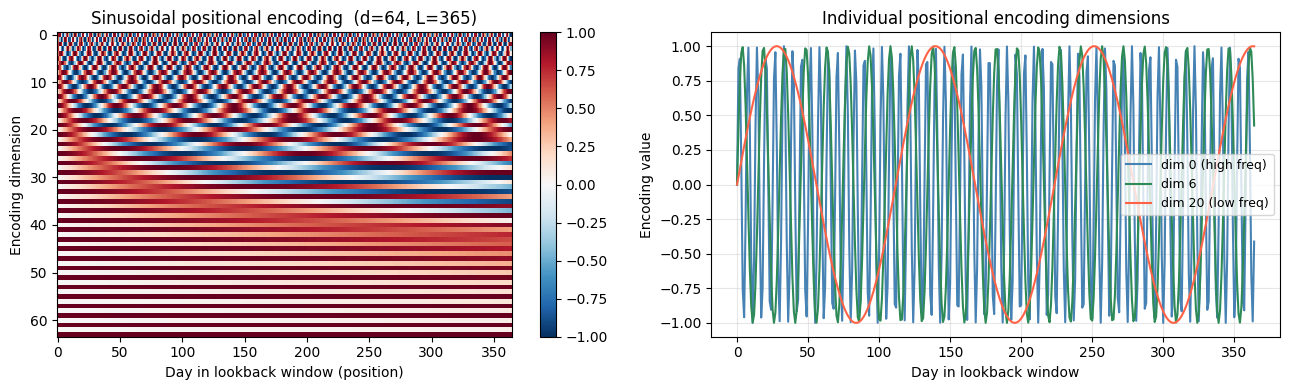

Low-index dimensions oscillate quickly (short-range order);
high-index dimensions oscillate slowly (long-range order).


In [5]:
class PositionalEncoding(nn.Module):
    """
    Adds sinusoidal positional encoding to the input.

    Args:
        d_model: feature dimension after the input projection
        max_len: maximum sequence length (≥ LOOKBACK)
        dropout: regularisation applied after adding the encoding
    """
    def __init__(self, d_model: int, max_len: int = 512, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        # Build the encoding table once and register as a non-trainable buffer
        pe = torch.zeros(max_len, d_model)           # [max_len, d_model]
        pos = torch.arange(max_len).unsqueeze(1)     # [max_len, 1]
        # Frequencies: 1 / 10000^(2i/d_model)
        div_term = torch.exp(
            torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(pos * div_term)
        pe[:, 1::2] = torch.cos(pos * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))  # [1, max_len, d_model]

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: [B, L, d_model]
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


# Visualise the encoding
pe_vis = PositionalEncoding(d_model=64, max_len=LOOKBACK, dropout=0.0)
pe_matrix = pe_vis.pe[0].numpy()  # [365, 64]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

im = axes[0].imshow(pe_matrix.T, aspect='auto', cmap='RdBu_r',
                    vmin=-1, vmax=1, interpolation='nearest')
axes[0].set_xlabel('Day in lookback window (position)')
axes[0].set_ylabel('Encoding dimension')
axes[0].set_title('Sinusoidal positional encoding  (d=64, L=365)')
plt.colorbar(im, ax=axes[0])
axes[0].grid(False)

# Show a few individual dimensions (low-freq vs high-freq)
for dim, lbl, col in [(0, 'dim 0 (high freq)', 'steelblue'),
                       (6, 'dim 6',             'seagreen'),
                       (20, 'dim 20 (low freq)', 'tomato')]:
    axes[1].plot(pe_matrix[:, dim], label=lbl, color=col, lw=1.5)
axes[1].set_xlabel('Day in lookback window')
axes[1].set_ylabel('Encoding value')
axes[1].set_title('Individual positional encoding dimensions')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Low-index dimensions oscillate quickly (short-range order);\n"
      "high-index dimensions oscillate slowly (long-range order).")

## 4. Multi-head attention

A single attention head computes one set of $\alpha_{ts}$ weights. But a 365-day sequence likely has **multiple independent patterns**: short-term precipitation events, a seasonal baseline, slowly varying soil moisture anomalies. Multi-head attention runs $H$ attention heads in parallel, each learning different $W_Q^h, W_K^h, W_V^h$ projections:

$$\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, \ldots, \text{head}_H)\, W_O$$

$$\text{head}_h = \text{Attention}(QW_Q^h,\, KW_K^h,\, VW_V^h)$$

Each head operates on a $d_k = d_{\text{model}}/H$ dimensional subspace, so total compute is the same as one full-dimensional head. The concatenation + $W_O$ projection mixes the information across heads.

**Hydrological interpretation of heads**: one head might learn to attend to recent large precipitation events (short lag), while another learns to attend to the seasonal moisture cycle (long lag). We'll visualise this in Section 6.

## 5. The encoder-only Transformer for regression

The full encoder layer stacks two sublayers with residual connections and layer normalisation:

$$\mathbf{Z}^{(\ell)} = \text{LayerNorm}\!\left(\mathbf{Z}^{(\ell-1)} + \text{MultiHead}(\mathbf{Z}^{(\ell-1)})\right)$$
$$\mathbf{Z}^{(\ell+1)} = \text{LayerNorm}\!\left(\mathbf{Z}^{(\ell)} + \text{FFN}(\mathbf{Z}^{(\ell)})\right)$$

where FFN is a two-layer MLP applied **independently to each time step** (same weights, different inputs).

After $N_{\text{layers}}$ encoder blocks, each day has a **contextualised representation** — a vector that summarises both its own features and the relevant features of all other days it attended to.

For **regression**, we need a single scalar output. We have two common choices:
- **Mean pooling**: average the final representations across all $L$ time steps
- **CLS token**: prepend a learnable `[CLS]` token and use its final representation

We use **mean pooling** here — it is simpler and forces the model to aggregate information from the whole window, which suits the continuous regression setting.

$$\hat{Q}_t = W_{\text{out}}\,\frac{1}{L}\sum_{s=1}^{L} \mathbf{Z}_s^{(N)}$$

The full pipeline is:

```
[B, L, 2]  →  input_proj  →  [B, L, d_model]
           →  + pos_enc
           →  TransformerEncoder (N layers of MHA + FFN)
           →  mean over L  →  [B, d_model]
           →  linear head  →  [B, 1]
```

In [6]:
class HydrologyTransformer(nn.Module):
    """
    Encoder-only Transformer for scalar sequence regression.

    Architecture:
      input_proj  : linear layer to lift the 2-feature input to d_model dimensions
      pos_enc     : sinusoidal positional encoding
      encoder     : stack of TransformerEncoderLayer blocks
      head        : mean pooling + linear regression head

    Args:
        n_features : number of input features (2: P, T)
        d_model    : internal representation dimension
        nhead      : number of attention heads (must divide d_model)
        num_layers : number of encoder blocks
        dim_ff     : feed-forward hidden dimension
        dropout    : dropout rate
        max_len    : maximum sequence length
    """
    def __init__(self,
                 n_features: int = 2,
                 d_model:    int = 64,
                 nhead:      int = 4,
                 num_layers: int = 2,
                 dim_ff:     int = 128,
                 dropout:    float = 0.1,
                 max_len:    int = 512):
        super().__init__()

        # 1. Project the 2-dimensional day-vector into the model space
        self.input_proj = nn.Linear(n_features, d_model)

        # 2. Add positional information
        self.pos_enc = PositionalEncoding(d_model, max_len=max_len, dropout=dropout)

        # 3. Transformer encoder (PyTorch's built-in implementation)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_ff,
            dropout=dropout,
            batch_first=True,   # input shape: [B, L, d_model]
            norm_first=True,    # pre-LayerNorm (more stable training)
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # 4. Regression head
        self.head = nn.Linear(d_model, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: [B, L, n_features]
        z = self.input_proj(x)          # [B, L, d_model]
        z = self.pos_enc(z)             # [B, L, d_model]
        z = self.encoder(z)             # [B, L, d_model]
        z = z.mean(dim=1)               # [B, d_model]   — mean pool over time
        return self.head(z)             # [B, 1]

    def get_attention_weights(self, x: torch.Tensor):
        """
        Forward pass that returns the attention weight matrices from all layers.
        Returns: output [B,1], list of attention matrices each [B, nhead, L, L]
        """
        attn_weights = []
        z = self.pos_enc(self.input_proj(x))
        for layer in self.encoder.layers:
            # Call the self-attention sub-layer directly to get weights
            z_norm = layer.norm1(z) if hasattr(layer, 'norm1') else z
            _, w = layer.self_attn(z_norm, z_norm, z_norm,
                                   need_weights=True, average_attn_weights=False)
            attn_weights.append(w.detach().cpu())  # [B, nhead, L, L]
            # Continue the full layer forward
            z = layer(z)
        output = self.head(z.mean(dim=1))
        return output, attn_weights


transformer = HydrologyTransformer(
    n_features=2, d_model=64, nhead=4, num_layers=2, dim_ff=128, dropout=0.1
).to(device)

def count_params(m):
    return sum(p.numel() for p in m.parameters())

print(f"Transformer params: {count_params(transformer):,}")
print()

# Sanity-check the forward pass
with torch.no_grad():
    test_out = transformer(xb.to(device))
print(f"Output shape: {test_out.shape}  (expected [64, 1])")

Transformer params: 67,201

Output shape: torch.Size([64, 1])  (expected [64, 1])


## 6. Training

In [8]:
def train_model(model, train_dl, val_dl, n_epochs=60, lr=1e-3, patience=10,
                warmup_epochs=5):
    """
    Standard training loop with Adam, gradient clipping, and early stopping.
    Includes a brief linear learning-rate warmup, which helps Transformers
    avoid instability in the first few epochs (attention weights start random).
    """
    opt     = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    history = {'train': [], 'val': []}
    best_val   = float('inf')
    best_state = None
    no_improve = 0

    for epoch in range(n_epochs):
        # Linear LR warmup
        if epoch < warmup_epochs:
            scale = (epoch + 1) / warmup_epochs
            for pg in opt.param_groups:
                pg['lr'] = lr * scale

        model.train()
        train_loss = 0.0
        for xb, yb in train_dl:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss = loss_fn(pred, yb)
            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            train_loss += loss.item()
        train_loss /= len(train_dl)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_dl:
                xb, yb = xb.to(device), yb.to(device)
                val_loss += loss_fn(model(xb), yb).item()
        val_loss /= len(val_dl)

        history['train'].append(train_loss)
        history['val'].append(val_loss)

        if val_loss < best_val:
            best_val   = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1

        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1:3d}/{n_epochs}  train={train_loss:.4f}  val={val_loss:.4f}")

        if no_improve >= patience:
            print(f"  Early stop at epoch {epoch+1}")
            break

    model.load_state_dict(best_state)
    return history


print("Training Transformer...")
trans_hist = train_model(transformer, train_dl, val_dl, n_epochs=10, lr=5e-4, patience=2)

Training Transformer...
  Early stop at epoch 5


## 7. Evaluation and comparison with LSTM

We retrain a reference LSTM (same hyperparameters as the previous notebook) for a direct comparison.

In [10]:
class LSTMModel(nn.Module):
    def __init__(self, n_features, hidden=64):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden, batch_first=True)
        self.head = nn.Linear(hidden, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :])

lstm = LSTMModel(n_features=2, hidden=64).to(device)
print(f"LSTM params: {count_params(lstm):,}")
print("Training LSTM...")
lstm_hist = train_model(lstm, train_dl, val_dl, n_epochs=8, lr=1e-3, patience=2)

LSTM params: 17,473
Training LSTM...
  Early stop at epoch 5


In [11]:
def predict(model, dl):
    model.eval()
    preds = []
    with torch.no_grad():
        for xb, _ in dl:
            preds.append(model(xb.to(device)).cpu().numpy())
    return np.concatenate(preds).squeeze()

def denorm_q(q_norm):
    return np.exp(q_norm * q_std + q_mean) - eps

def calc_metrics(true, pred):
    rmse  = np.sqrt(np.mean((true - pred) ** 2))
    nse   = 1 - np.sum((true - pred) ** 2) / np.sum((true - np.mean(true)) ** 2)
    pbias = 100 * np.sum(pred - true) / np.sum(true)
    return {'RMSE': rmse, 'NSE': nse, 'PBias (%)': pbias}

test_true = test_q_raw[LOOKBACK:]

results = {}
for name, model in [('LSTM', lstm), ('Transformer', transformer)]:
    pred_norm = predict(model, test_dl)
    pred_mm   = np.clip(denorm_q(pred_norm), 0, None)
    results[name] = {'pred': pred_mm, 'metrics': calc_metrics(test_true, pred_mm)}

print("Test set performance:")
print(f"{'Model':<12} {'RMSE (mm/d)':>14} {'NSE':>8} {'PBias (%)':>12}")
print('-' * 50)
for name, r in results.items():
    m = r['metrics']
    print(f"{name:<12} {m['RMSE']:>14.4f} {m['NSE']:>8.4f} {m['PBias (%)']:>12.2f}")

Test set performance:
Model           RMSE (mm/d)      NSE    PBias (%)
--------------------------------------------------
LSTM                 2.0114   0.6335       -20.63
Transformer          2.8234   0.2779        -9.19


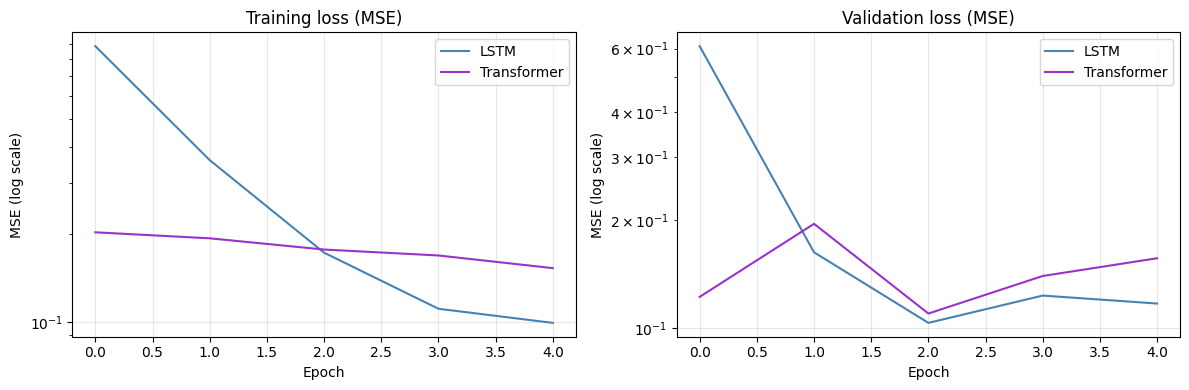

In [12]:
# Learning curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = {'LSTM': 'steelblue', 'Transformer': 'darkorchid'}

for name, hist in [('LSTM', lstm_hist), ('Transformer', trans_hist)]:
    axes[0].semilogy(hist['train'], label=name, color=colors[name])
    axes[1].semilogy(hist['val'],   label=name, color=colors[name])

for ax, title in zip(axes, ['Training loss (MSE)', 'Validation loss (MSE)']):
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE (log scale)')
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

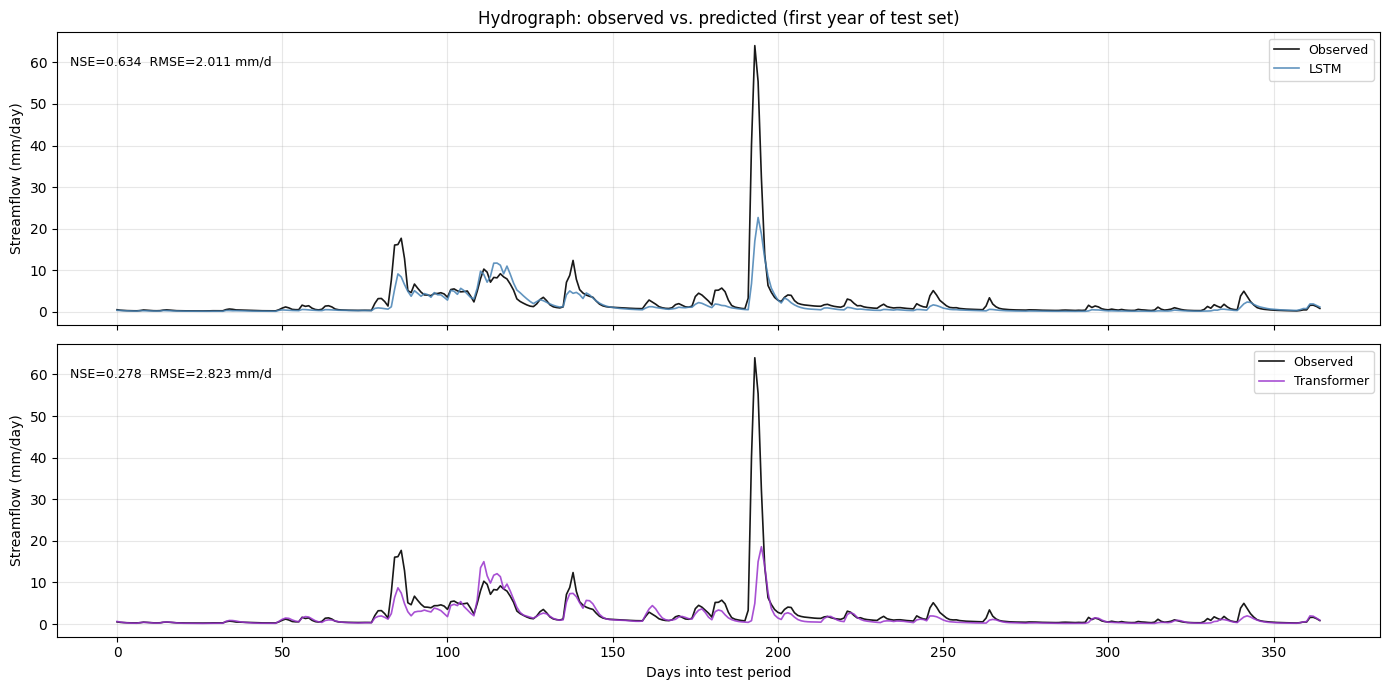

In [13]:
# Hydrograph — first year of test set
plot_days = 365
obs = test_true[:plot_days]

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

for ax, (name, color) in zip(axes, [('LSTM', 'steelblue'), ('Transformer', 'darkorchid')]):
    pred = results[name]['pred'][:plot_days]
    m    = results[name]['metrics']
    ax.plot(obs,  color='black', lw=1.2, label='Observed', alpha=0.9)
    ax.plot(pred, color=color,   lw=1.2, label=name,       alpha=0.85)
    ax.set_ylabel('Streamflow (mm/day)')
    ax.legend(loc='upper right', fontsize=9)
    ax.text(0.01, 0.92,
            f"NSE={m['NSE']:.3f}  RMSE={m['RMSE']:.3f} mm/d",
            transform=ax.transAxes, fontsize=9, va='top')
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('Days into test period')
axes[0].set_title('Hydrograph: observed vs. predicted (first year of test set)')
plt.tight_layout()
plt.show()

## 8. Visualising what the Transformer attends to

One advantage of attention-based models over LSTMs is **interpretability**: the attention weights $\alpha_{ts}$ tell us explicitly which past days the model borrows information from.

We'll examine the attention patterns for a **flood event** in the test set, asking:
- Does the model attend to recent heavy precipitation?
- Are there longer-lag patterns (soil moisture memory)?
- Do different heads specialise in different lag scales?

In [18]:
# Find a flood event in the test set (high observed streamflow)
flood_idx = int(np.argmax(test_q_raw[LOOKBACK:LOOKBACK+600])) + LOOKBACK
print(f"Flood peak: day {flood_idx} in test array,"
      f" Q = {test_q_raw[flood_idx]:.2f} mm/day")

# Build the lookback window ending at the flood peak
x_flood = test_x[flood_idx - LOOKBACK : flood_idx]  # [LOOKBACK, 2]
x_tensor = torch.tensor(x_flood, dtype=torch.float32).unsqueeze(0).to(device)  # [1, L, 2]

transformer.eval()
with torch.no_grad():
    pred_norm, attn_list = transformer.get_attention_weights(x_tensor)

pred_mm = float(denorm_q(pred_norm.cpu().numpy().squeeze()))
true_mm = float(test_q_raw[flood_idx])
print(f"Prediction: {pred_mm:.2f} mm/day  |  True: {true_mm:.2f} mm/day")

# attn_list: list of tensors [1, nhead, L, L] — one per encoder layer
# We examine layer 0 (four heads)
attn_l0 = attn_list[0][0].numpy()  # [nhead, L, L]

Flood peak: day 558 in test array, Q = 64.01 mm/day
Prediction: 4.95 mm/day  |  True: 64.01 mm/day


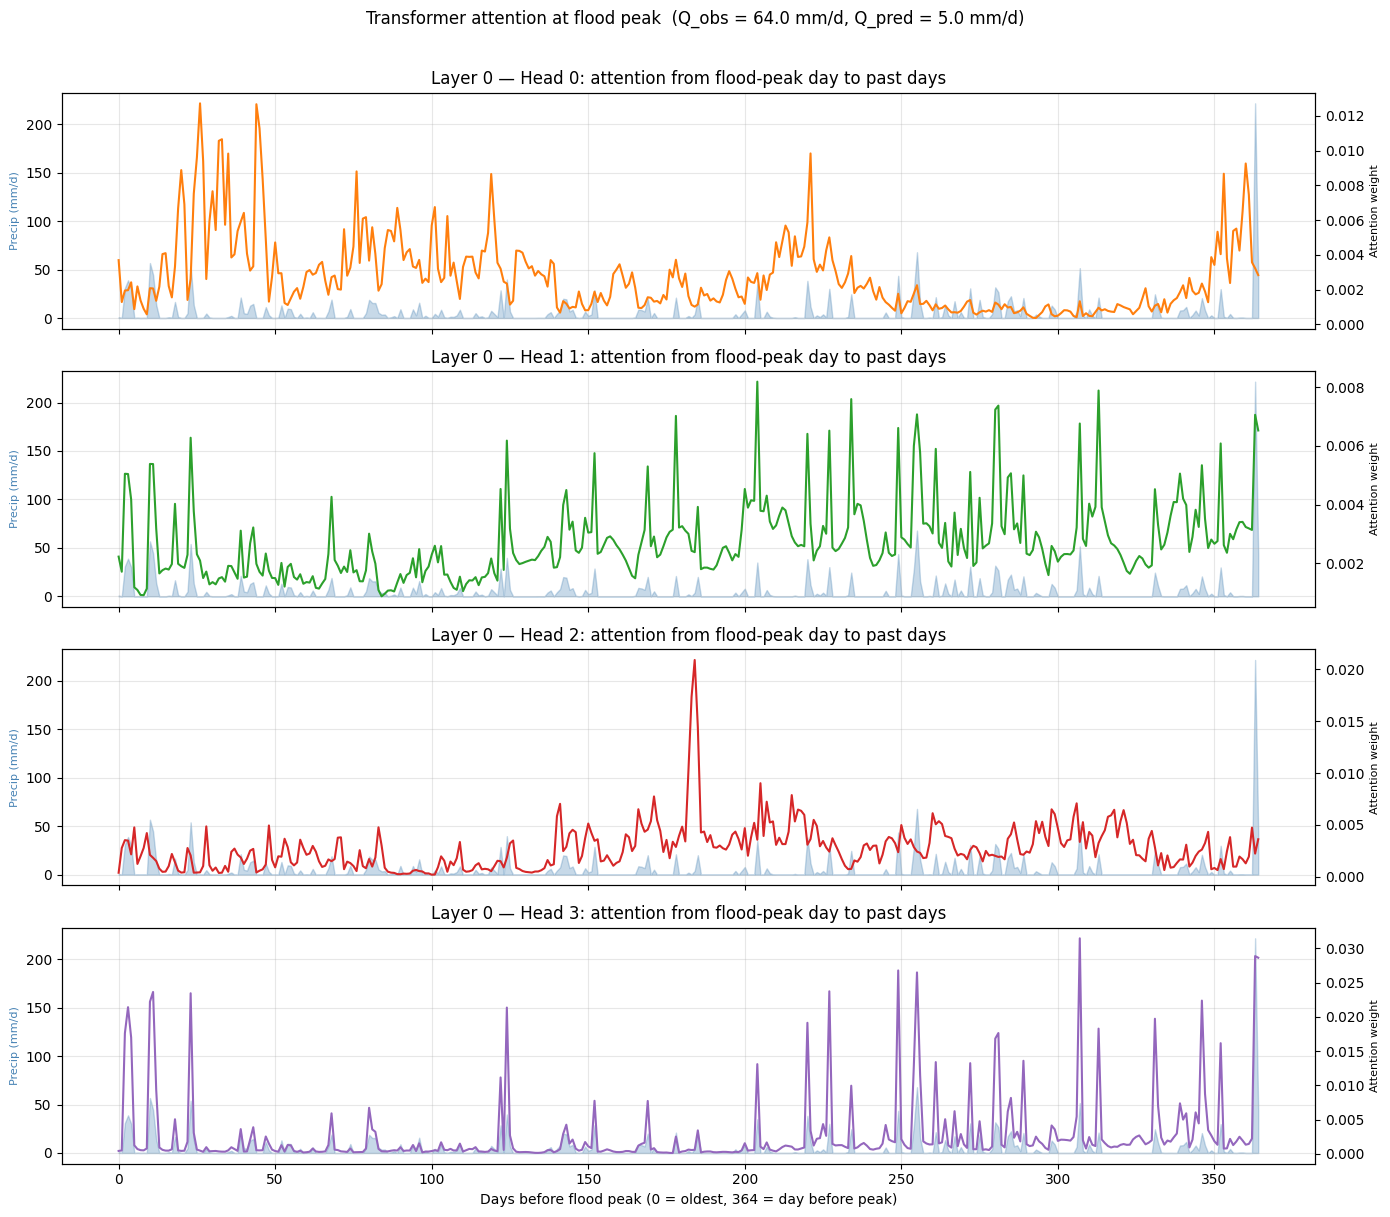

In [19]:
# For each head: attention FROM the last day (the query day we predict for)
# to all source days in the lookback window

p_mm = x_flood[:, 0] * scaler_x.scale_[0] + scaler_x.mean_[0]  # precipitation in mm
days = np.arange(LOOKBACK)

n_heads = attn_l0.shape[0]
fig, axes = plt.subplots(n_heads, 1, figsize=(14, 3 * n_heads), sharex=True)

for h, ax in enumerate(axes):
    # Attention from the last query position (index L-1) to all source positions
    attn_h = attn_l0[h, -1, :]  # [L]

    ax.fill_between(days, p_mm, color='steelblue', alpha=0.3, label='Precip (mm/day)')
    ax.set_ylabel('Precip (mm/d)', color='steelblue', fontsize=8)

    ax2 = ax.twinx()
    ax2.plot(days, attn_h, color=f'C{h+1}', lw=1.5, label=f'Head {h} attention')
    ax2.set_ylabel('Attention weight', fontsize=8)

    ax.set_title(f'Layer 0 — Head {h}: attention from flood-peak day to past days')
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('Days before flood peak (0 = oldest, 364 = day before peak)')
plt.suptitle(f'Transformer attention at flood peak  (Q_obs = {true_mm:.1f} mm/d,'
             f' Q_pred = {pred_mm:.1f} mm/d)', y=1.01)
plt.tight_layout()
plt.show()

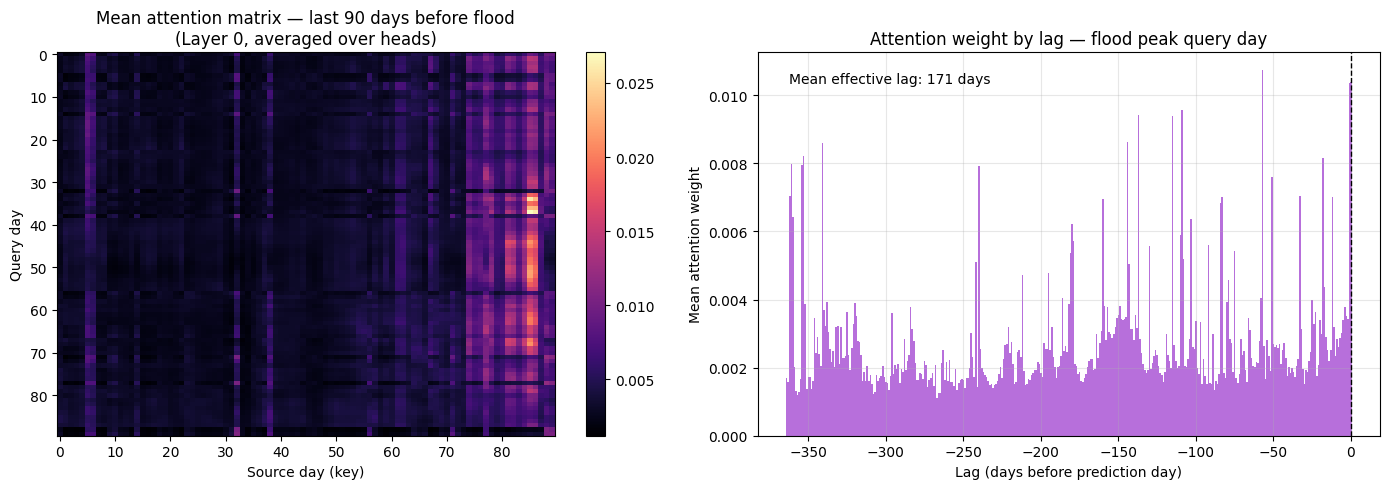

In [20]:
# Full attention matrix (mean across heads, layer 0) — shows global attention structure
attn_mean = attn_l0.mean(axis=0)  # [L, L]

# Show a 90-day sub-window near the flood for clarity
N = 90
start = LOOKBACK - N
sub = attn_mean[start:, start:]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im = axes[0].imshow(sub, aspect='auto', cmap='magma',
                    origin='upper', interpolation='nearest')
axes[0].set_xlabel('Source day (key)')
axes[0].set_ylabel('Query day')
axes[0].set_title(f'Mean attention matrix — last {N} days before flood\n(Layer 0, averaged over heads)')
plt.colorbar(im, ax=axes[0])
axes[0].grid(False)

# Lag histogram: for the last query day, where is the attention mass?
attn_last_mean = attn_mean[-1]  # [L]
lags = np.arange(LOOKBACK) - (LOOKBACK - 1)  # negative = days before peak

axes[1].bar(lags, attn_last_mean, width=1, color='darkorchid', alpha=0.7)
axes[1].axvline(0, color='black', lw=1, ls='--')
axes[1].set_xlabel('Lag (days before prediction day)')
axes[1].set_ylabel('Mean attention weight')
axes[1].set_title('Attention weight by lag — flood peak query day')
axes[1].grid(alpha=0.3)

# Annotate the effective attention lag
effective_lag = int(np.average(np.abs(lags), weights=attn_last_mean))
axes[1].text(0.05, 0.92, f'Mean effective lag: {effective_lag} days',
             transform=axes[1].transAxes, fontsize=10)

plt.tight_layout()
plt.show()

## 9. Scaling behaviour: model size vs. performance

Unlike LSTMs — where performance is mostly governed by `hidden_size` — Transformers have several orthogonal knobs: depth, width, heads, and feedforward size. We sweep depth (`num_layers`) and width (`d_model`) to see which matters most on this dataset.

  d32-L1...   Epoch  10/10  train=0.2046  val=0.3795
NSE=0.365  params=8,673
  d64-L1...   Epoch  10/10  train=0.1801  val=0.1248
NSE=0.315  params=33,729
  d64-L2...   Epoch  10/10  train=0.1220  val=0.0762
  Early stop at epoch 10
NSE=0.516  params=67,201
  d128-L2...   Epoch  10/10  train=0.1134  val=0.1723
NSE=0.555  params=265,473


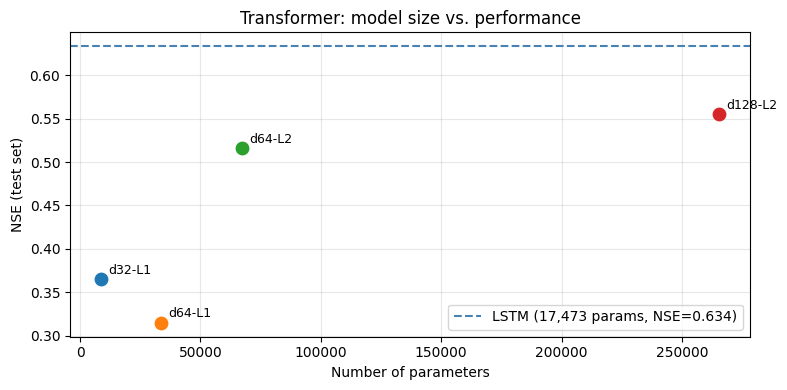

In [22]:
configs = [
    dict(d_model=32,  nhead=2, num_layers=1, dim_ff=64,  label='d32-L1'),
    dict(d_model=64,  nhead=4, num_layers=1, dim_ff=128, label='d64-L1'),
    dict(d_model=64,  nhead=4, num_layers=2, dim_ff=128, label='d64-L2'),
    dict(d_model=128, nhead=4, num_layers=2, dim_ff=256, label='d128-L2'),
]

sweep_results = {}
for cfg in configs:
    label = cfg.pop('label')
    print(f"  {label}...", end=' ')
    m = HydrologyTransformer(n_features=2, **cfg, dropout=0.1).to(device)
    _ = train_model(m, train_dl, val_dl, n_epochs=10, lr=5e-4, patience=4)
    pred_mm = np.clip(denorm_q(predict(m, test_dl)), 0, None)
    nse = calc_metrics(test_true, pred_mm)['NSE']
    n_params = count_params(m)
    sweep_results[label] = {'NSE': nse, 'params': n_params}
    print(f"NSE={nse:.3f}  params={n_params:,}")

fig, ax = plt.subplots(figsize=(8, 4))
for label, res in sweep_results.items():
    ax.scatter(res['params'], res['NSE'], s=80, zorder=3)
    ax.annotate(label, (res['params'], res['NSE']),
                textcoords='offset points', xytext=(5, 4), fontsize=9)

# Reference: our main LSTM
lstm_nse = results['LSTM']['metrics']['NSE']
ax.axhline(lstm_nse, color='steelblue', ls='--', lw=1.5,
           label=f'LSTM ({count_params(lstm):,} params, NSE={lstm_nse:.3f})')
ax.set_xlabel('Number of parameters')
ax.set_ylabel('NSE (test set)')
ax.set_title('Transformer: model size vs. performance')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Summary

| Concept | Key point |
|---------|----------|
| **Self-attention** | Learned weighted average: each day's output is a convex combination of all other days' value vectors, with weights computed from query-key dot products |
| **Positional encoding** | Sinusoidal basis functions injected into the input to give the model access to temporal order (without it, attention is permutation-invariant) |
| **Multi-head attention** | $H$ independent attention patterns in parallel; different heads can learn different lag structures (short-term event vs. seasonal memory) |
| **Encoder-only for regression** | No decoder needed; the lookback window is encoded → mean-pooled → linear head produces a scalar prediction |
| **Attention weights as interpretability** | Unlike LSTM hidden states, attention maps directly show which past days the model draws from — analogous to an impulse-response function |
| **LSTM vs. Transformer** | Both handle long sequences; LSTM has implicit memory through recurrence, Transformer has explicit direct access via attention. Neither dominates — performance depends on dataset size and lookback length |

### Looking Ahead

The encoder-only Transformer we built here is the backbone of models like BERT (for classification/regression) and Vision Transformers (ViT). A few natural extensions for hydrology:

- **Multi-catchment pretraining**: train on dozens of basins, fine-tune on a target catchment with limited data (the "foundation model" paradigm for hydrology, e.g. NeuralHydrology)
- **Cross-attention over spatial inputs**: use a decoder-style cross-attention to fuse satellite soil moisture maps with point-scale forcing
- **Continuous-time positional encodings**: replace sinusoidal encodings with encodings derived from the actual calendar date — useful for irregular observations or sub-daily data